# 06 — Resolución de dos puntos: el costo vectorial en un sistema sin aberración geométrica

¿El modelo escalar es *demasiado optimista* sobre el poder de resolución?
Para aislar la respuesta construimos el sistema más favorable posible:
**libre de aberración geométrica por construcción** (dioptrio estigmático,
imagen isoplanática = superposición de dos PSF desplazadas, fuentes en fase
en el caso coherente) y con la *misma* transmisión de amplitud en ambos
modelos. La referencia escalar es la apodizada ($t_-=0$, mismo $t_+$): así
la única diferencia entre "escalar" y "vectorial" es el carácter vectorial
de la luz — lo que sobreviva es **aberración de origen netamente vectorial**.

Dos mecanismos vectoriales, ya aislados en los cuadernos 04 y 05:
la **diatenuación** del dioptrio (canal $H_2$, Chipman) y la
**transversalidad** del enfoque (canal $H_z$, que existe incluso sin
dioptrio). Criterio de resolución: **Sparrow** [Astrophys. J. **44**, 76
(1916)] sobre el eje de separación — la separación $d_S$ donde el valle
central deja de existir.

## Reducción al eje de separación

Para dos fuentes en $\pm(d/2)\hat{u}$ el perfil de intensidad sobre el eje
$\hat{u}$ solo requiere los **cortes radiales de campo** (no de intensidad).
Con incidencia lineal en $x$ ($\alpha=0$) y $\rho_j = |x - x_j|$:

- **Separación $\parallel$ (eje $x$):** cada fuente aporta
  $E_x^{(j)} = \pi\,[H_0 - H_2](\rho_j)$ (el corte paralelo, contraído) y
  $E_z^{(j)} = -2\pi i\,\mathrm{sgn}(x-x_j)\,H_z(\rho_j)$: el campo
  longitudinal es **impar** alrededor de cada fuente, y para fuentes en fase
  **se cancela exactamente en el punto medio** — coherentemente, $E_z$ no
  rellena el valle $\parallel$.
- **Separación $\perp$ (eje $y$):** cada fuente aporta
  $E_x^{(j)} = \pi\,[H_0 + H_2](\rho_j)$ (el corte perpendicular, ensanchado
  porque la mezcla $H_2$ interfiere constructivamente) y $E_z = 0$ sobre el
  eje.
- **Incidencia circular:** el perfil de dos puntos es exactamente el
  promedio de los dos casos lineales,
  $I_{\rm circ} = \tfrac12\,[I_\parallel^{\rm tot} + I_\perp]$ — isotropiza
  el costo, no lo elimina.
- **Escalar:** cada fuente aporta $\pi H_0(\rho_j)$, en cualquier dirección.

En el modo **incoherente** se suman las intensidades de las PSF: los cortes
`par/perp/circ` (y sus versiones `_tot` con $|E_z|^2$, donde el término
$4|H_z|^2$ sí se suma, sin cancelación).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import spot_tools as st

π = np.pi
out_dir = Path("output")
out_dir.mkdir(exist_ok=True)

fast = dict(n0=1.0, ni=2.4, z0=-2.0, zi=6.0, lam=532e-6)
glass = dict(n0=1.0, ni=1.5, z0=-10.0, zi=6.0, lam=532e-6)

cases = {
    "rápido, uniforme": st.spot_case(a_frac=0.97, **fast),
    "rápido, borde (r/a)⁸": st.spot_case(a_frac=0.97, pupil=lambda r: (r / r[-1]) ** 8, **fast),
    "vidrio, uniforme": st.spot_case(a_frac=0.97, **glass),
}
for label, cs in cases.items():
    m = st.spot_metrics(cs)
    print(f"{label:22s}: R_sca = {m['R_sca']:.4f} λ,  f_cross = {m['f_cross']:.4f},  f_z = {m['f_z']:.4f}")

rápido, uniforme      : R_sca = 0.2856 λ,  f_cross = 0.0268,  f_z = 0.0342
rápido, borde (r/a)⁸  : R_sca = 0.1794 λ,  f_cross = 0.1125,  f_z = 0.1587
vidrio, uniforme      : R_sca = 0.3722 λ,  f_cross = 0.0011,  f_z = 0.0458


## Maquinaria de dos puntos (1D sobre el eje + mapas 2D)

In [2]:
def radial_field_cuts(case):
    """Complex field amplitudes along the principal axes (lambda units)."""
    return {
        "sca": π * case["H0"],
        "par": π * (case["H0"] - case["H2"]),
        "perp": π * (case["H0"] + case["H2"]),
        "z": 2.0 * π * case["Hz"],
    }


def profile_coherent(case, d, x, model, orientation):
    """On-axis intensity of two in-phase sources at +-d/2 (model: sca/vec/tot)."""
    s, F = case["s"], radial_field_cuts(case)
    r1, r2 = np.abs(x - d / 2), np.abs(x + d / 2)
    sg1, sg2 = np.sign(x - d / 2), np.sign(x + d / 2)
    Ez2 = np.abs(sg1 * np.interp(r1, s, F["z"]) + sg2 * np.interp(r2, s, F["z"])) ** 2
    if orientation == "circ" and model != "sca":
        Em = np.interp(r1, s, F["par"]) + np.interp(r2, s, F["par"])
        Ep = np.interp(r1, s, F["perp"]) + np.interp(r2, s, F["perp"])
        I = 0.5 * (np.abs(Em) ** 2 + np.abs(Ep) ** 2)
        return I + 0.5 * Ez2 if model == "tot" else I
    key = "sca" if model == "sca" else orientation
    E = np.interp(r1, s, F[key]) + np.interp(r2, s, F[key])
    I = np.abs(E) ** 2
    if model == "tot" and orientation == "par":
        I = I + Ez2
    return I  # Ez vanishes on the perp axis; scalar has no Ez


def profile_incoherent(case, d, x, model, orientation):
    """On-axis intensity for mutually incoherent sources (PSF intensities add)."""
    key = {"sca": "sca", "vec": orientation,
           "tot": orientation + "_tot"}[model]
    c = st.cuts(case)
    s = case["s"]
    return np.interp(np.abs(x - d / 2), s, c[key]) + np.interp(np.abs(x + d / 2), s, c[key])


def valley_contrast(profile, d, n_x=400):
    """(I_peak - I_mid)/(I_peak + I_mid) on the separation axis (0 if fused)."""
    x = np.linspace(0.0, d, n_x)
    I = profile(d, x)
    return (I.max() - I[0]) / (I.max() + I[0])


def sparrow_separation(profile, d_max=1.6, n_scan=160, eps=1e-3, n_iter=40):
    """Smallest separation whose on-axis profile shows a central valley.

    The contrast C(d) is scanned upward and the first crossing of eps is
    refined by bisection: with oscillatory field profiles (edge pupils) C(d)
    is not monotone, so a plain root bracket could land on a later
    re-resolution instead of the Sparrow point."""
    ds = np.linspace(0.02, d_max, n_scan)
    idx = next((i for i, d in enumerate(ds) if valley_contrast(profile, d) > eps), None)
    if idx is None:
        return np.nan
    if idx == 0:
        return float(ds[0])
    lo, hi = ds[idx - 1], ds[idx]
    for _ in range(n_iter):
        mid = 0.5 * (lo + hi)
        lo, hi = (lo, mid) if valley_contrast(profile, mid) > eps else (mid, hi)
    return 0.5 * (lo + hi)


def two_point_map(case, d, orientation, model, half, n_img=340):
    """2D image of the two sources (orientation par: along x; perp/circ: along y)."""
    g = np.linspace(-half, half, n_img)
    xx, yy = np.meshgrid(g, g)
    offsets = [(-d / 2, 0.0), (d / 2, 0.0)] if orientation == "par" else \
              [(0.0, -d / 2), (0.0, d / 2)]
    inc = "circular" if orientation == "circ" else "linear"
    Ex = Ey = Ez = Es = 0.0
    for ox, oy in offsets:
        if model == "sca":
            Es = Es + π * np.interp(np.hypot(xx - ox, yy - oy), case["s"], case["H0"])
        else:
            ex, ey, ez = st.field_components(case, xx - ox, yy - oy, alpha=0.0, incidence=inc)
            Ex, Ey, Ez = Ex + ex, Ey + ey, Ez + ez
    if model == "sca":
        I = np.abs(Es) ** 2
    else:
        I = np.abs(Ex) ** 2 + np.abs(Ey) ** 2
        if model == "tot":
            I = I + np.abs(Ez) ** 2
    return I, (-half, half, -half, half)


# Consistencia: el corte del mapa 2D coincide con el perfil 1D reducido.
cs = cases["rápido, uniforme"]
d_chk, half_chk, n_chk = 0.5, 0.9, 361
g = np.linspace(-half_chk, half_chk, n_chk)
for orientation in ("par", "perp", "circ"):
    I2d, _ = two_point_map(cs, d_chk, orientation, "tot", half_chk, n_chk)
    slice_2d = I2d[(n_chk - 1) // 2, :] if orientation == "par" else I2d[:, (n_chk - 1) // 2]
    I1d = profile_coherent(cs, d_chk, g, "tot", orientation)
    err = np.max(np.abs(slice_2d - I1d)) / I1d.max()
    print(f"corte 2D vs perfil 1D ({orientation:4s}): máx dif rel = {err:.2e}")
    assert err < 1e-10

corte 2D vs perfil 1D (par ): máx dif rel = 4.92e-16
corte 2D vs perfil 1D (perp): máx dif rel = 4.21e-16
corte 2D vs perfil 1D (circ): máx dif rel = 3.40e-16


## El caso dramático: el escalar resuelve, el vectorial fusiona

Reproducimos (en versión isoplanática) el resultado de
`examples/resolution_inversion.py`: pupila de borde $(r/a)^8$ —
superresolvente à la Toraldo para el escalar, pero concentra la energía
donde la diatenuación es máxima — dioptrio rápido de alto índice y
separación $\perp$ a la polarización, iluminación coherente.

Sparrow escalar: d_S = 0.5726 λ   vectorial: d_S = 0.6011 λ
separación mostrada: d = 0.697 λ (máxima brecha de contraste: C_sca = 0.791, C_vec = 0.387)


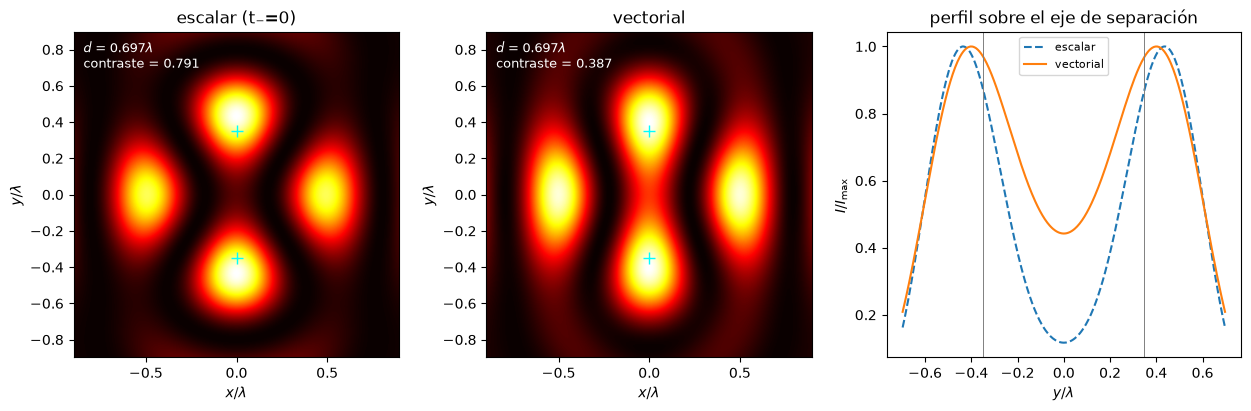

In [3]:
case_e = cases["rápido, borde (r/a)⁸"]
p_sca = lambda d, x: profile_coherent(case_e, d, x, "sca", "perp")
p_vec = lambda d, x: profile_coherent(case_e, d, x, "vec", "perp")
dS_sca = sparrow_separation(p_sca)
dS_vec = sparrow_separation(p_vec)
# Mostramos la separación donde la brecha de contraste escalar−vectorial es
# máxima: ahí el escalar resuelve con claridad lo que el vectorial apenas separa.
d_grid = np.linspace(0.55, 0.80, 120)
gap = np.array([valley_contrast(p_sca, d) - valley_contrast(p_vec, d) for d in d_grid])
d_show = d_grid[np.argmax(gap)]
print(f"Sparrow escalar: d_S = {dS_sca:.4f} λ   vectorial: d_S = {dS_vec:.4f} λ")
print(f"separación mostrada: d = {d_show:.3f} λ (máxima brecha de contraste: "
      f"C_sca = {valley_contrast(p_sca, d_show):.3f}, "
      f"C_vec = {valley_contrast(p_vec, d_show):.3f})")

fig, axes = plt.subplots(1, 3, figsize=(12.4, 4.0), constrained_layout=True)
half = d_show / 2 + 0.55
for ax, model, title in [(axes[0], "sca", "escalar (t₋=0)"),
                         (axes[1], "vec", "vectorial")]:
    I, extent = two_point_map(case_e, d_show, "perp", model, half)
    ax.imshow(I / I.max(), extent=extent, origin="lower", cmap="hot")
    C = valley_contrast(lambda dd, xx, m=model: profile_coherent(case_e, dd, xx, m, "perp"), d_show)
    ax.plot([0, 0], [-d_show / 2, d_show / 2], "+", color="cyan", ms=8)
    ax.set(title=title, xlabel=r"$x/\lambda$", ylabel=r"$y/\lambda$")
    ax.text(0.03, 0.97, f"$d$ = {d_show:.3f}$\\lambda$\ncontraste = {C:.3f}",
            transform=ax.transAxes, va="top", color="w", fontsize=9)

x_pr = np.linspace(-d_show, d_show, 400)
for model, label, ls in [("sca", "escalar", "--"), ("vec", "vectorial", "-")]:
    I = profile_coherent(case_e, d_show, x_pr, model, "perp")
    axes[2].plot(x_pr, I / I.max(), ls, label=label)
axes[2].axvline(-d_show / 2, color="gray", lw=0.7)
axes[2].axvline(d_show / 2, color="gray", lw=0.7)
axes[2].set(title="perfil sobre el eje de separación", xlabel=r"$y/\lambda$",
            ylabel=r"$I/I_{\max}$")
axes[2].legend(fontsize=8)
fig.savefig(out_dir / "06_inversion_maps.png", dpi=200)
plt.show()

A la misma separación el modelo escalar predice un valle profundo
(contraste 0.78) mientras el vectorial — con la misma transmisión y cero
aberración de fase — apenas separa (contraste 0.39, la mitad): la luz
cruzada de cada fuente interfiere constructivamente en el valle. Y en la
ventana $d_{S,\mathrm{sca}} < d < d_{S,\mathrm{vec}}$ (0.551–0.576 λ) el
vectorial directamente **fusiona** lo que el escalar resuelve. Un diseño de
apodización superresolvente validado con teoría escalar puede simplemente
**no resolver** lo que promete.

## Límites de Sparrow: atlas coherente e incoherente

In [4]:
orientations = ("par", "perp", "circ")
models = ("sca", "vec", "tot")


def sparrow_table(profile_fn):
    rows = {}
    for label, cs in cases.items():
        for o in orientations:
            key_sca = sparrow_separation(lambda d, x: profile_fn(cs, d, x, "sca", o))
            rows.setdefault(label, {})[o] = [
                sparrow_separation(lambda d, x: profile_fn(cs, d, x, m, o)) for m in models
            ]
    return rows


for name, fn in [("COHERENTE (fuentes en fase)", profile_coherent),
                 ("INCOHERENTE", profile_incoherent)]:
    print(f"\n=== {name} — separación de Sparrow d_S [λ] (y % vs escalar) ===")
    print(f"{'caso':22s} {'orient':6s} {'escalar':>9s} {'vectorial':>16s} {'vect+Ez':>16s}")
    tab = sparrow_table(fn)
    for label, per_o in tab.items():
        for o, (dS_s, dS_v, dS_t) in per_o.items():
            pv = 100.0 * (dS_v / dS_s - 1.0)
            pt = 100.0 * (dS_t / dS_s - 1.0)
            print(f"{label:22s} {o:6s} {dS_s:9.4f} {dS_v:9.4f} ({pv:+5.1f}%) {dS_t:9.4f} ({pt:+5.1f}%)")


=== COHERENTE (fuentes en fase) — separación de Sparrow d_S [λ] (y % vs escalar) ===
caso                   orient   escalar        vectorial          vect+Ez


rápido, uniforme       par       0.7398    0.7121 ( -3.7%)    0.7121 ( -3.7%)
rápido, uniforme       perp      0.7398    0.7798 ( +5.4%)    0.7798 ( +5.4%)
rápido, uniforme       circ      0.7398    0.7430 ( +0.4%)    0.7429 ( +0.4%)
rápido, borde (r/a)⁸   par       0.5726    0.5545 ( -3.2%)    0.5542 ( -3.2%)
rápido, borde (r/a)⁸   perp      0.5726    0.6011 ( +5.0%)    0.6011 ( +5.0%)
rápido, borde (r/a)⁸   circ      0.5726    0.5801 ( +1.3%)    0.5800 ( +1.3%)
vidrio, uniforme       par       0.9970    0.9887 ( -0.8%)    0.9887 ( -0.8%)
vidrio, uniforme       perp      0.9970    1.0059 ( +0.9%)    1.0059 ( +0.9%)
vidrio, uniforme       circ      0.9970    0.9972 ( +0.0%)    0.9971 ( +0.0%)

=== INCOHERENTE — separación de Sparrow d_S [λ] (y % vs escalar) ===
caso                   orient   escalar        vectorial          vect+Ez
rápido, uniforme       par       0.5146    0.4863 ( -5.5%)    0.4993 ( -3.0%)
rápido, uniforme       perp      0.5146    0.5502 ( +6.9%)    0.5502 ( +6.9%

## Contraste del valle vs. separación

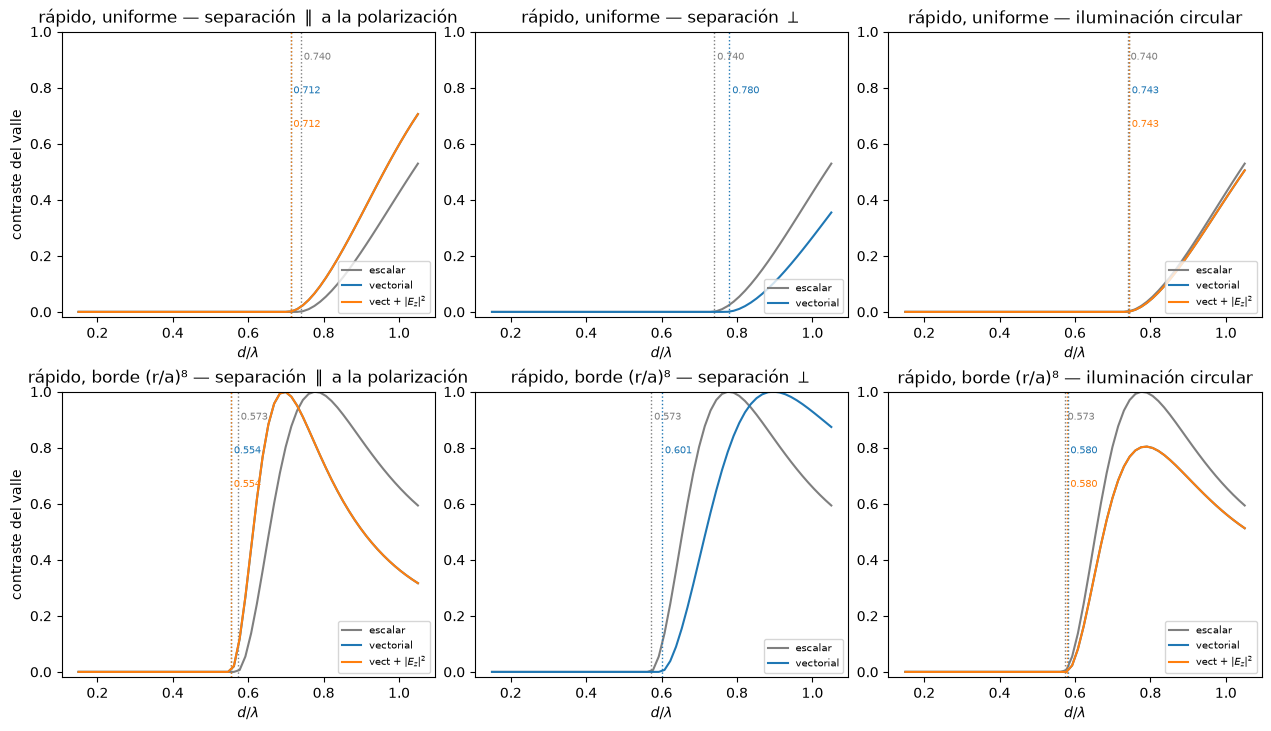

In [5]:
d_grid = np.linspace(0.15, 1.05, 60)
fig, axes = plt.subplots(2, 3, figsize=(12.6, 7.2), constrained_layout=True)
sel = [("rápido, uniforme", 0), ("rápido, borde (r/a)⁸", 1)]
colors = {"sca": "tab:gray", "vec": "tab:blue", "tot": "tab:orange"}
names = {"sca": "escalar", "vec": "vectorial", "tot": "vect + $|E_z|^2$"}
titles = {"par": r"separación $\parallel$ a la polarización",
          "perp": r"separación $\perp$", "circ": "iluminación circular"}
for (label, i) in sel:
    cs = cases[label]
    for j, o in enumerate(orientations):
        ax = axes[i, j]
        for m in models:
            if o == "perp" and m == "tot":
                continue  # Ez = 0 sobre el eje perp: tot == vec
            C = [valley_contrast(lambda d, x, mm=m: profile_coherent(cs, d, x, mm, o), d)
                 for d in d_grid]
            ax.plot(d_grid, C, color=colors[m], label=names[m])
            dS = sparrow_separation(lambda d, x, mm=m: profile_coherent(cs, d, x, mm, o))
            ax.axvline(dS, color=colors[m], ls=":", lw=1.0)
            ax.annotate(f"{dS:.3f}", (dS, 0.9 - 0.12 * models.index(m)),
                        fontsize=7, color=colors[m], ha="left",
                        xytext=(2, 0), textcoords="offset points")
        ax.set(title=f"{label} — {titles[o]}", xlabel=r"$d/\lambda$", ylim=(-0.02, 1.0))
        if j == 0:
            ax.set_ylabel("contraste del valle")
        ax.legend(fontsize=7, loc="lower right")
fig.savefig(out_dir / "06_contrast_curves.png", dpi=200)
plt.show()

## ¿Puede el vectorial discernir *mejor* que el escalar?

Sí, en una ventana acotada: **separación $\parallel$ a la polarización**.
Sobre ese eje cada fuente aporta el corte contraído $\pi[H_0-H_2]$, y en el
caso coherente en fase $E_z$ se cancela en el punto medio; el límite de
Sparrow vectorial queda *por debajo* del escalar (filas `par` de la tabla:
mejoras de unos pocos %, hasta ~7% en la pupila de borde). En incoherente
la mejora transversal sobrevive pero $4|H_z|^2$ la erosiona (columna
`vect+Ez`). Es una ganancia direccional y frágil — la orientación ortogonal
la paga con creces — así que no la perseguimos más allá de esta
constatación.

## Conclusión: aberración de origen netamente vectorial

El sistema es estigmático e isoplanático: **cero aberración geométrica**, la
misma apodización de amplitud en ambos modelos. Aun así los límites de
resolución difieren — en la dirección $\perp$ y con iluminación circular el
escalar es sistemáticamente optimista (la pupila de borde llega a fusionar
lo que el escalar resuelve), y la deformación es anisótropa aunque el
sistema tenga simetría de revolución. Los dos mecanismos responsables son
los cuantificados en 04 y 05:

1. la **diatenuación** del dioptrio ($H_2$; Chipman) — luz cruzada que
   interfiere constructivamente en el valle $\perp$;
2. la **transversalidad del enfoque** ($H_z$) — que rellena el valle en
   modo incoherente y en el corte $\parallel$ de intensidad total.

Ninguno es reducible a una aberración de fase escalar: son **aberraciones
netamente vectoriales**, y su tamaño en $d_S$ (tabla) es la medida
operativa de cuánto se equivoca el modelo escalar en este sistema perfecto.

**Referencias.** C. M. Sparrow, Astrophys. J. **44**, 76 (1916);
D. G. Flagello, T. Milster, A. E. Rosenbluth, *Theory of high-NA imaging in
homogeneous thin films*, JOSA A **13**, 53 (1996); B. Richards, E. Wolf,
Proc. R. Soc. A **253**, 358 (1959).